**2. MOCO TRAINING**

In [20]:
import digitalhub as dh
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_NAME = "floods"
project = dh.get_project(PROJECT_NAME)
print(f"Project: {project.name}")

Project: floods


**SETUP PARAMETERS**

In [21]:
job_name = "net_v2"                                     
dataset = "Standard"                                                                                                            

parameters = {
    "job_name": job_name,
    "dataset": dataset,
    "simple_proj": False,
    "attn": False,
    "max_series": 0,  

    "batch_size": 16,
    "patch_size": 256,
    "n_images1": 4, "n_channels1": 2,              
    "n_images2": 4, "n_channels2": 10,              
    "moco_dim": 128,
    "moco_k": 4096,                                     
    "moco_t": 0.07,
    "moco_m": 0.999,
    "hidden_channels_dim": 64,   
    "workers": 0,                               
}

volumes = [
    {
        "volume_type": "ephemeral",
        "name": "volume-spazio-dati",
        "mount_path": "/data",      
        "spec": {"size": "500Gi"}   
    }
]

**BUILD ENVIRONMENT**

In [22]:
moco_2D_train_func = project.new_function(
    name= f'moco_2D_EVAL_{job_name}',
    kind="python",
    python_version="PYTHON3_10",
    code_src="../src/", 
    handler="eval_moco_retrieval", 
    base_image="pytorch/pytorch:2.1.2-cuda11.8-cudnn8-runtime",
    requirements=["pandas==2.3.3", "numpy==1.26.4", "rasterio==1.4.4", "tqdm==4.70.0", "tifffile==2024.8.30", "torch==2.1.2", "matplotlib==3.10.9", "digitalhub==0.15.11", "digitalhub-runtime-python==0.15.2"]
)

build = moco_2D_train_func.run("build", wait=True)
print(f"BUILD: {build.status.state}")

2026-09-28 11:26:48,407 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:26:53,414 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:26:58,423 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:27:03,431 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:27:08,440 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:27:13,448 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11:27:18,457 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run f3b2cd2097f04de1929856296c45b4dd to finish...
2026-09-28 11

BUILD: COMPLETED


**TRAINING**

In [23]:
run_moco_2D = moco_2D_train_func.run(
    action="job", 
    parameters=parameters, 
    volumes=volumes, 
    profile="1xv100-shared",
    local_execution= False,                       
    wait=True
)

print(f"Run moco avviato: {run_moco_2D.id}")

2026-09-28 11:27:39,094 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:27:44,101 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:27:49,109 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:27:54,221 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:27:59,230 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:28:04,345 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11:28:09,354 - dhcore.digitalhub.entities.run._base.entity - INFO - Waiting for run a0bfc79ab6a641b6a846f25a99244bfc to finish...
2026-09-28 11

Run moco avviato: a0bfc79ab6a641b6a846f25a99244bfc


**PLOTS**

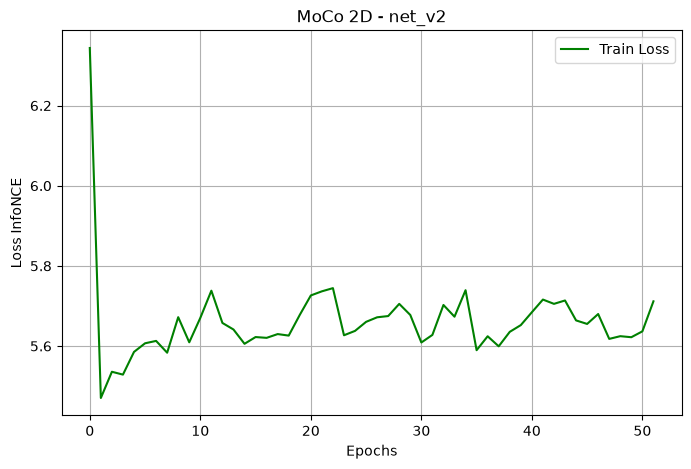

In [24]:
path = project.get_artifact(f"moco_2D_metrics_{job_name}").download(overwrite=True)
df = pd.read_csv(path)

plt.figure(figsize=(8, 5))
plt.plot(df['epoch'], df['train_loss'], color='green', label='Train Loss')
plt.title(f'MoCo 2D - {job_name}')
plt.xlabel('Epochs')
plt.ylabel('Loss InfoNCE')
plt.grid(True)
plt.legend()
plt.show()